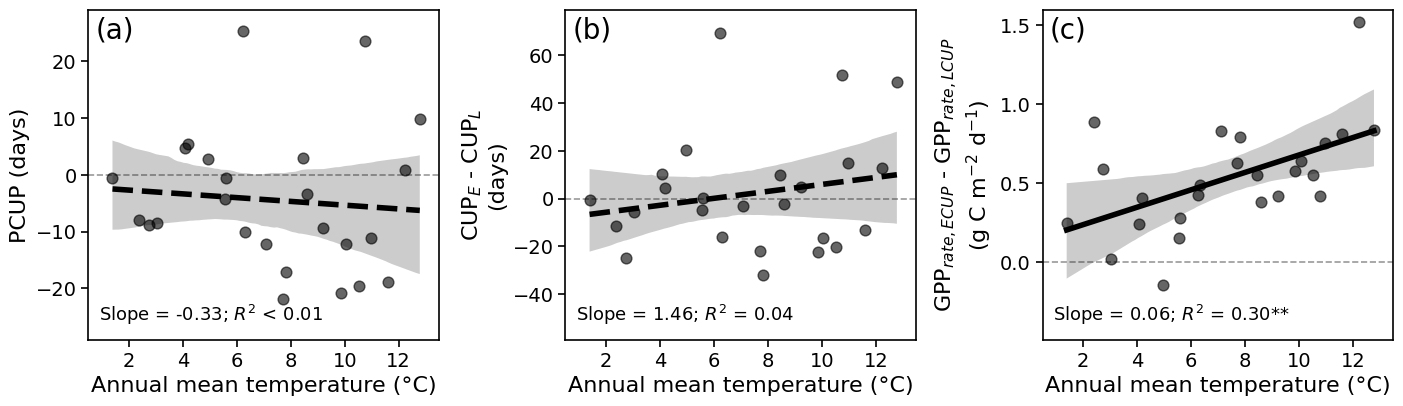

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ============================================================
# 0) Read data
# ============================================================
FILE_PATH = "../../data_results/2_results/2-6_gpp_pos_partition/GPP_POS_ECUP_LCUP_summary_ecosystem.xlsx"

df = pd.read_excel(FILE_PATH)
df = df[df["year"] > 2016].copy()

CO2_COL = "co2"
X_COL = "temp_mean_anom"
ECO2 = 500

line_color = "black"
box_color = "0.55"

# ============================================================
# 1) Helpers
# ============================================================
def p_to_stars(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


def fmt_p_text(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""


def style_ax(ax, labelsize=12):
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=labelsize,
        length=5,
        width=1.2,
        direction="out",
        bottom=True,
        left=True
    )
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)


def fit_models_and_choose(x, y, aic_delta=None, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return {
            "chosen": "linear",
            "model": None,
            "p_model": np.nan,
            "linestyle": "--",
            "aic_lin": np.nan,
            "aic_quad": np.nan,
        }

    X1 = sm.add_constant(x)
    m1 = sm.OLS(y, X1).fit()
    aic1 = float(m1.aic)

    X2 = sm.add_constant(np.column_stack([x, x**2]))
    m2 = sm.OLS(y, X2).fit()
    aic2 = float(m2.aic)

    if aic_delta is not None and aic2 < aic1 - aic_delta:
        chosen = "quad"
        model = m2
        p_model = float(m2.f_pvalue)
    else:
        chosen = "linear"
        model = m1
        p_model = float(m1.f_pvalue)

    linestyle = "-" if p_model < alpha else "--"

    return {
        "chosen": chosen,
        "model": model,
        "p_model": p_model,
        "linestyle": linestyle,
        "aic_lin": aic1,
        "aic_quad": aic2,
    }


def format_reg_text(fit, nd_slope=2, nd_r2=2):
    if fit["model"] is None:
        return "Insufficient data"

    if fit["chosen"] == "linear":
        _, b1 = fit["model"].params
        r2 = float(fit["model"].rsquared)
        p = float(fit["p_model"])

        r2s = (
            f"$R^2$ = {r2:.{nd_r2}f}"
            if r2 > 0.01
            else "$R^2$ < 0.01"
        )

        return f"Slope = {b1:.{nd_slope}f}; {r2s}{fmt_p_text(p)}"

    else:
        r2 = float(fit["model"].rsquared)
        p = float(fit["p_model"])

        return f"Quadratic; $R^2$ = {r2:.{nd_r2}f}; {fmt_p_text(p)}"


def draw_reg(
    ax,
    x,
    y,
    color,
    order,
    linestyle,
    scatter_alpha=0.6,
    line_alpha=1.0,
    size=60,
    lw=4
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return

    sns.regplot(
        x=x,
        y=y,
        ax=ax,
        order=order,
        scatter_kws={
            "alpha": scatter_alpha,
            "color": color,
            "s": size
        },
        line_kws={
            "linestyle": linestyle,
            "alpha": line_alpha,
            "linewidth": lw
        },
        color=color
    )

    if len(ax.collections) > 1:
        ax.collections[-1].set_alpha(0.20)


def draw_inset_box(ax_parent, y, color, loc="upper right"):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]

    axins = inset_axes(
        ax_parent,
        width="27%",
        height="36%",
        loc=loc,
        borderpad=1.0
    )

    dd = pd.DataFrame({
        "Group": ["eCO$_2$"] * len(y),
        "y": y
    })

    sns.boxplot(
        data=dd,
        x="Group",
        y="y",
        ax=axins,
        width=0.45,
        fliersize=0,
        color=color,
        linewidth=1.4,
        boxprops=dict(linewidth=1.4),
        whiskerprops=dict(linewidth=1.4),
        capprops=dict(linewidth=1.4),
        medianprops=dict(linewidth=1.4, color="white")
    )

    sns.stripplot(
        data=dd,
        x="Group",
        y="y",
        ax=axins,
        color="k",
        alpha=0.55,
        size=3.8,
        jitter=0.10
    )

    axins.axhline(
        0,
        color="gray",
        linewidth=0.9,
        linestyle="--",
        alpha=0.8,
        zorder=0
    )

    # one-sample t-test against 0
    if len(y) >= 2:
        _, p = stats.ttest_1samp(y, 0)
        mark = p_to_stars(p)
    else:
        mark = "NA"

    axins.text(
        0.5,
        0.97,
        mark,
        ha="center",
        va="top",
        transform=axins.transAxes,
        fontsize=10
    )

    axins.set_xlabel("")
    axins.set_ylabel("")
    axins.set_xticks([])
    axins.set_xticklabels([])
    axins.tick_params(
        axis="both",
        labelsize=8,
        length=2.5,
        width=0.8,
        direction="out"
    )

    for spine in axins.spines.values():
        spine.set_linewidth(0.9)

    return axins


def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}")


# ============================================================
# 2) Prepare data: eCO2 only
# ============================================================
df_e = df[df[CO2_COL] == ECO2].copy()

PCUP_COL = pick_col(df_e, ["doy_gppmax_anom"])

ECUP_ANOM_COL = pick_col(df_e, ["ECUP_anom", "EGS_anom"])
LCUP_ANOM_COL = pick_col(df_e, ["LCUP_anom", "LGS_anom"])

RATE_ECUP_ANOM_COL = pick_col(
    df_e,
    ["GPP_rate_ecup_anom", "GPP_rate_egs_anom"]
)

RATE_LCUP_ANOM_COL = pick_col(
    df_e,
    ["GPP_rate_lcup_anom", "GPP_rate_lgs_anom"]
)

# ------------------------------------------------------------
# 1) PCUP
# ------------------------------------------------------------
d_pcup = df_e[[X_COL, PCUP_COL]].dropna().copy()

x_pcup = d_pcup[X_COL].to_numpy(float)
y_pcup = d_pcup[PCUP_COL].to_numpy(float)

# ------------------------------------------------------------
# 2) ECUP - LCUP duration
# ------------------------------------------------------------
d_cup = df_e[[X_COL, ECUP_ANOM_COL, LCUP_ANOM_COL]].dropna().copy()
d_cup["diff"] = d_cup[ECUP_ANOM_COL] - d_cup[LCUP_ANOM_COL]

x_cup = d_cup[X_COL].to_numpy(float)
y_cup = d_cup["diff"].to_numpy(float)

# ------------------------------------------------------------
# 3) GPPrate_ECUP - GPPrate_LCUP
# ------------------------------------------------------------
d_rate = df_e[
    [X_COL, RATE_ECUP_ANOM_COL, RATE_LCUP_ANOM_COL]
].dropna().copy()

d_rate["diff"] = (
    d_rate[RATE_ECUP_ANOM_COL]
    - d_rate[RATE_LCUP_ANOM_COL]
)

x_rate = d_rate[X_COL].to_numpy(float)
y_rate = d_rate["diff"].to_numpy(float)

panel_data = [
    {
        "panel": "(a)",
        "x": x_pcup,
        "y": y_pcup,
        "ylabel": "PCUP (days)",
        "ylim": (-29, 29),
        "text_pos": (0.03, 0.04),
        "inset_loc": "upper right",
    },
    {
        "panel": "(b)",
        "x": x_cup,
        "y": y_cup,
        "ylabel": "CUP$_{E}$ - CUP$_{L}$\n(days)",
        "ylim": (-59, 79),
        "text_pos": (0.03, 0.04),
        "inset_loc": "upper right",
    },
    {
        "panel": "(c)",
        "x": x_rate,
        "y": y_rate,
        "ylabel": (
            "GPP$_{rate,ECUP}$ - GPP$_{rate,LCUP}$\n"
            "(g C m$^{-2}$ d$^{-1}$)"
        ),
        "ylim": (-0.49, 1.6),
        "text_pos": (0.03, 0.04),
        "inset_loc": "upper right",
    },
]

# ============================================================
# 3) Plot: horizontal panels with inset boxplots
# ============================================================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(14.5, 4.4),
    sharex=True,
    sharey=False
)

for ax, cfg in zip(axes, panel_data):

    x = cfg["x"]
    y = cfg["y"]

    ax.set_ylim(cfg["ylim"])

    ax.text(
        0.02,
        0.98,
        cfg["panel"],
        transform=ax.transAxes,
        fontsize=20,
        ha="left",
        va="top"
    )

    fit = fit_models_and_choose(
        x,
        y,
        aic_delta=None,
        alpha=0.05
    )

    draw_reg(
        ax,
        x,
        y,
        color=line_color,
        order=1 if fit["chosen"] == "linear" else 2,
        linestyle=fit["linestyle"],
        scatter_alpha=0.6,
        size=60,
        lw=4
    )

    ax.axhline(
        0,
        color="gray",
        linewidth=1.2,
        linestyle="--",
        alpha=0.8,
        zorder=0
    )

    txt = format_reg_text(
        fit,
        nd_slope=2,
        nd_r2=2
    )

    tx, ty = cfg["text_pos"]

    ax.text(
        tx,
        ty,
        txt,
        fontsize=13,
        transform=ax.transAxes,
        color=line_color,
        va="bottom"
    )

    # draw_inset_box(
    #     ax,
    #     y,
    #     color=box_color,
    #     loc=cfg["inset_loc"]
    # )

    ax.set_xlabel(
        "Annual mean temperature (°C)",
        fontsize=16
    )

    ax.set_ylabel(
        cfg["ylabel"],
        fontsize=16
    )

    ax.set_xlim(0.5, 13.5)
    ax.set_xticks([2, 4, 6, 8, 10, 12])

    style_ax(ax, labelsize=14)

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.18,
    top=0.93,
    wspace=0.36
)

plt.show()